In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Optional, Tuple
import matplotlib.pyplot as plt
import numpy as np
import i24_motion_macro
import i24_motion_data
import optuna

In [154]:
@dataclass
class TriangularFD:
    """
    Triangular fundamental diagram (per lane):
      - free-flow branch: q = v_f * rho
      - congested branch: q = w * (rho_j - rho)
    Units (SI recommended):
      rho: veh/m
      q:   veh/s
      v_f: m/s
      w:   m/s  (positive magnitude of backward wave speed)
      rho_j: veh/m
    """
    v_f: float    # free-flow speed (m/s)
    w: float      # congestion wave speed magnitude (m/s), positive
    rho_j: float  # jam density (veh/m)

    """
    @property
    def rho_c(self) -> float:
        # critical density where v_f * rho = w * (rho_j - rho)
        return (self.w / (self.v_f + self.w)) * self.rho_j
    """

    @staticmethod
    def flow(rho, v_f, w, rho_j):
        return v_f*rho*(1.0 - (rho/rho_j))

    @property
    def rho_c(self) -> float:
        return self.rho_j / 2.0

    @property
    def q_max(self) -> float:
        return self.flow(self.rho_c, self.v_f, self.w, self.rho_j)
    
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        #print("Demand: ")
        #print(rho)
        rho_old = rho
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.minimum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        #print("Supply: ")
        #print(rho)
        rho = np.clip(rho, 0.0, self.rho_j)
        rho = np.maximum(rho, self.rho_c)
        #print(rho)
        flow = self.flow(rho, self.v_f, self.w, self.rho_j)
        #print(flow)
        return flow

    """
    def demand(self, rho: np.ndarray) -> np.ndarray:
        '''D(rho): sending flow from an upstream cell.'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.v_f * rho, self.q_max)


    def supply(self, rho: np.ndarray) -> np.ndarray:
        '''S(rho): receiving flow into a downstream cell'''
        rho = np.clip(rho, 0.0, self.rho_j)
        return np.minimum(self.w * (self.rho_j - rho), self.q_max)
    """


@dataclass
class CTMConfig:
    dx: float  # cell length (m)
    dt: float  # time step (s)
    lanes: int
    lambda_lc: float = 0.0


    def check_cfl(self, fd: TriangularFD) -> None:
        # CTM/Godunov stability: dt <= dx / max(v_f, w)
        vmax = max(fd.v_f, fd.w)
        if self.dt > self.dx / vmax + 1e-12:
            raise ValueError(
                f"CFL violated: dt={self.dt} > dx/max(v_f,w)={self.dx/vmax:.6f}"
            )


class CTMSolver:
    """
    Multi-lane CTM solver (lanes are independent here).
    rho shape: (lanes, n_cells)

    Coupling:
      - You can specify measured boundary flows (veh/s per lane):
          q_left[l]  : flow entering cell 0 from left boundary
          q_right[l] : flow leaving last cell to right boundary
        If not provided, solver uses "open boundary" by default:
          q_left  = demand(virtual upstream density) limited by supply(cell0)
          q_right = demand(lastcell) limited by supply(virtual downstream density)
        But for micro–macro coupling, you typically provide q_left/q_right
        from spawn/despawn counters (or metering gate logic).
    """
    def __init__(self, rho_init: np.ndarray, fd: TriangularFD, cfg: CTMConfig):
        if rho_init.ndim != 2:
            raise ValueError("rho_init must be 2D: (lanes, n_cells)")
        if rho_init.shape[0] != cfg.lanes:
            raise ValueError("rho_init lanes mismatch")
        self.rho = rho_init.astype(np.float64, copy=True)
        self.fd = fd
        self.cfg = cfg
        self.cfg.check_cfl(fd)

    @property
    def lanes(self) -> int:
        return self.cfg.lanes

    @property
    def n_cells(self) -> int:
        return self.rho.shape[1]

    def step(
        self,
        q_left: Optional[np.ndarray] = None,
        q_right: Optional[np.ndarray] = None,
        rho_upstream: Optional[np.ndarray] = None,
        rho_downstream: Optional[np.ndarray] = None,
    ) -> Tuple[np.ndarray, np.ndarray]:
        """
        Advance one CTM step.

        Inputs:
          q_left:  shape (lanes,) measured inflow into cell 0 (veh/s)
          q_right: shape (lanes,) measured outflow from last cell (veh/s)

          If q_left is None, you can provide rho_upstream (lanes,) as a "ghost density"
          to compute a Godunov boundary flux. Same for q_right with rho_downstream.

        Returns:
          (F, rho_new)
          F: interface fluxes shape (lanes, n_cells+1) where:
             F[:,0]       = left boundary inflow into cell 0
             F[:,i+1]     = flux from cell i -> i+1 (for i=0..n_cells-2)
             F[:,-1]      = right boundary outflow from last cell
        """
        L, N = self.rho.shape
        dx, dt = self.cfg.dx, self.cfg.dt

        #rho = np.clip(self.rho, 0.0, self.fd.rho_j)
        rho = self.rho

        # Compute interior demands/supplies
        D = self.fd.demand(rho)   # (L,N)
        S = self.fd.supply(rho)   # (L,N)

        # Flux array: interfaces 0..N (N+1 interfaces)
        F = np.zeros((L, N + 1), dtype=np.float64)

        # --- Left boundary flux F[:,0] ---
        if q_left is not None:
            q_left = np.asarray(q_left, dtype=np.float64)
            if q_left.shape != (L,):
                raise ValueError("q_left must have shape (lanes,)")
            # Can't exceed receiving capacity of cell 0
            F[:, 0] = np.clip(q_left, 0.0, S[:, 0])
        else:
            # Godunov/open boundary using upstream ghost density
            if rho_upstream is None:
                # default: "infinite demand" upstream (i.e., inject up to supply)
                D_up = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_upstream = np.asarray(rho_upstream, dtype=np.float64)
                rho_upstream = np.clip(rho_upstream, 0.0, self.fd.rho_j)
                if rho_upstream.shape != (L,):
                    raise ValueError("rho_upstream must have shape (lanes,)")
                D_up = self.fd.demand(rho_upstream)
            F[:, 0] = np.minimum(D_up, S[:, 0])

        # --- Interior fluxes F[:,1..N-1] (cell i -> i+1) ---
        for i in range(N - 1):
            F[:, i + 1] = np.minimum(D[:, i], S[:, i + 1])

        # --- Right boundary flux F[:,-1] ---
        if q_right is not None:
            q_right = np.asarray(q_right, dtype=np.float64)
            if q_right.shape != (L,):
                raise ValueError("q_right must have shape (lanes,)")
            # Can't exceed sending capacity of last cell
            F[:, -1] = np.clip(q_right, 0.0, D[:, -1])
        else:
            # Godunov/open boundary using downstream ghost density
            if rho_downstream is None:
                # default: "infinite supply" downstream (i.e., accept up to demand)
                S_dn = np.full((L,), self.fd.q_max, dtype=np.float64)
            else:
                rho_downstream = np.asarray(rho_downstream, dtype=np.float64)
                rho_downstream = np.clip(rho_downstream, 0.0, self.fd.rho_j)
                if rho_downstream.shape != (L,):
                    raise ValueError("rho_downstream must have shape (lanes,)")
                S_dn = self.fd.supply(rho_downstream)
            F[:, -1] = np.minimum(D[:, -1], S_dn)

        # --- Update densities by conservation ---
        # rho_i^{n+1} = rho_i^n - (dt/dx)(F_{i+1/2} - F_{i-1/2})            
        rho_new = rho - (dt / dx) * (F[:, 1:] - F[:, :-1])
        # --- Lane coupling: speed-difference incentive + gap acceptance ---
        if self.cfg.lambda_lc > 0.0 and self.cfg.lanes > 1:
            # Compute S_lateral from rho (not rho_new)
            v = np.divide(
                self.fd.flow(rho, self.fd.v_f, self.fd.w, self.fd.rho_j),
                np.maximum(rho, 1e-12)
            )
            p_gap = np.clip(1.0 - rho / self.fd.rho_j, 0.0, 1.0)

            S_lat = np.zeros((L + 1, N), dtype=np.float64)
            for i in range(1, L):
                dv_fwd = np.maximum(v[i] - v[i-1], 0.0) / self.fd.v_f
                dv_bwd = np.maximum(v[i-1] - v[i], 0.0) / self.fd.v_f
                S_lat[i] = self.cfg.lambda_lc * dv_fwd * rho[i-1] * p_gap[i] \
                        - self.cfg.lambda_lc * dv_bwd * rho[i]   * p_gap[i-1]

            lat_flux = (dt * (S_lat[:-1] - S_lat[1:]))
            # Make sure we don't go below zero density and don't exceed critical density
            lat_flux = np.clip(lat_flux, a_min=-rho_new, a_max=(self.fd.rho_j - rho_new))
            rho_new = rho_new + (dt * (S_lat[:-1] - S_lat[1:]))
            #rho_new = np.clip(rho_new, 0.0, self.fd.rho_j)
        # physical bounds
        #rho_new = np.clip(rho_new, 0.0, self.fd.rho_j)
        long_boundary_flux = (dt / dx) * (F[:, 0].sum() - F[:, -1].sum())
        mass_after = rho_new.sum()
        mass_before = self.rho.sum()
        residual = mass_after - mass_before - long_boundary_flux
        if abs(residual) > 1e-9:
            print(f"Mass not conserved: residual={residual:.2e}")
        self.rho = rho_new
        return F, rho_new

    def derived_flow_and_speed(self) -> Tuple[np.ndarray, np.ndarray]:
        """
        For diagnostics:
          q_cell = f(rho) (veh/s)
          v_cell = q_cell / rho (m/s), with safe handling of rho=0
        """
        rho = np.clip(self.rho, 0.0, self.fd.rho_j)
        q = np.minimum(self.fd.v_f * rho, self.fd.w * (self.fd.rho_j - rho))
        v = np.divide(q, np.maximum(rho, 1e-12))
        return q, v


# ---------------- Example usage ----------------

def sim_example():
    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 4
    n_cells = 200
    dx = 20.0   # m
    dt = 0.5    # s

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=33.0,        # 33 m/s ~ 74 mph
        w=5.0,           # 5 m/s ~ 11 mph backward wave speed magnitude
        rho_j=0.15       # 0.15 veh/m ~ 150 veh/km per lane
    )

    rho0 = np.zeros((lanes, n_cells), dtype=np.float64)
    rho0[:] = 0.02  # 0.02 veh/m = 20 veh/km per lane (light/moderate)

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=rho0, fd=fd, cfg=cfg)

    # Suppose micro bubble sits between some indices, and you measure interface flows:
    # Here: just inject a constant inflow at left and throttle outflow at right (toy example).
    q_left_measured  = np.array([0.30, 0.30, 0.30, 0.30], dtype=np.float64)  # veh/s per lane
    q_right_measured = np.array([0.10, 0.10, 0.10, 0.10], dtype=np.float64)  # veh/s per lane (congested downstream)

    for k in range(20):  # 10 seconds
        F, rho = ctm.step(q_left=q_left_measured, q_right=q_right_measured)
        q_cell, v_cell = ctm.derived_flow_and_speed()

    print("rho (lane0, first 10 cells):", rho[0, :10])
    print("flow boundary left/right lane0:", F[0, 0], F[0, -1])

In [92]:
sim_example()

No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
No lateral flow!
rho (lane0, first 10 cells): [0.0132 0.02   0.02   0.02   0.02   0.02   0.02   0.02   0.02   0.02  ]
flow boundary left/right lane0: 0.3 0.1


In [93]:
i24data = i24_motion_data.I24MotionData(2, 1669812350, 1669812350+3600, 0, 1600)
i24macro = i24_motion_macro.I24MotionMacro(i24data, 2, "road_2")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
i24macro_lane_data = i24macro.loadProcessedMacroData()

In [ ]:
i24macro_queries = i24macro.computeEdieBoxQueries()

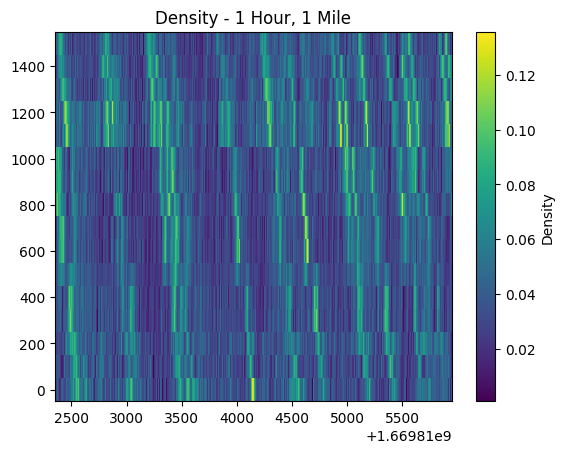

In [119]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16)).T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16)).T
density_result_display = np.array(i24macro_lane_data[-1]["density"].reshape((3600, 16)).T, dtype=np.float64)
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

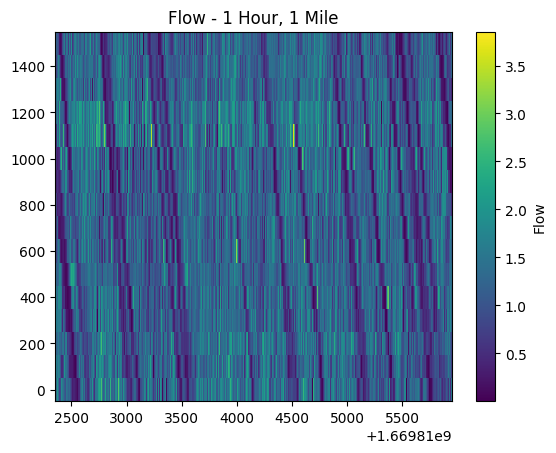

In [120]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16)).T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16)).T
flow_result_display = np.array(i24macro_lane_data[-1]["flow"].reshape((3600, 16)).T, dtype=np.float64)
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [121]:
def sim_real_data(lane_data, lane_flow, dx = 100.0, dt = 1.0, v_f=35.0, rho_j=0.10):
    lane_data = lane_data.reshape((3600, 16))
    lane_flow = lane_flow.reshape((3600, 16))

    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 1
    dx = dx
    dt = dt

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=v_f,
        w=0.0,
        rho_j=rho_j
    )

    lane_data_source = lane_data[:, 1:-1].reshape((1, 3600, 14))
    lane_flow_source = lane_flow[:, 1:-1].reshape((1, 3600, 14))
    rho_left_measured = lane_data[:, 0].reshape((1, 3600, 1))
    rho_right_measured = lane_data[:, -1].reshape((1, 3600, 1))

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes)
    ctm = CTMSolver(rho_init=lane_data_source[:, 0, :], fd=fd, cfg=cfg)

    result_density = np.zeros((3600, 14), dtype=np.float64)
    result_density[0, :] = lane_data_source[0, 0, :]
    result_flow = np.zeros((3600, 14), dtype=np.float64)
    result_flow[0, :] = lane_flow_source[0, 0, :]
    for k in range(3600 - 1):  # 1 hour
        F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
        result_density[k+1, :] = rho
        result_flow[k + 1, :] = F[:, 1:]
        #result[k+1, 0] = rho_left_measured[:, k, 0]
        #result[k+1, -1] = rho_right_measured[:, k, 0]
        #q_cell, v_cell = ctm.derived_flow_and_speed()
    return result_density, result_flow

In [122]:
source_density = np.array(i24macro_lane_data[-1]["density"], dtype=np.float64)
source_flow = np.array(i24macro_lane_data[-1]["flow"], dtype=np.float64)
sim_density, sim_flow = sim_real_data(source_density, source_flow)
sim_flow = sim_flow

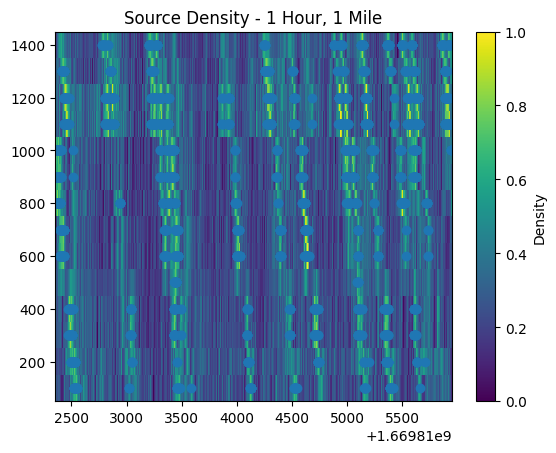

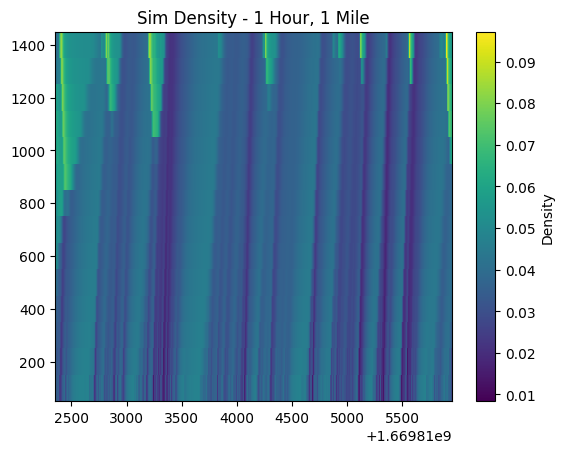

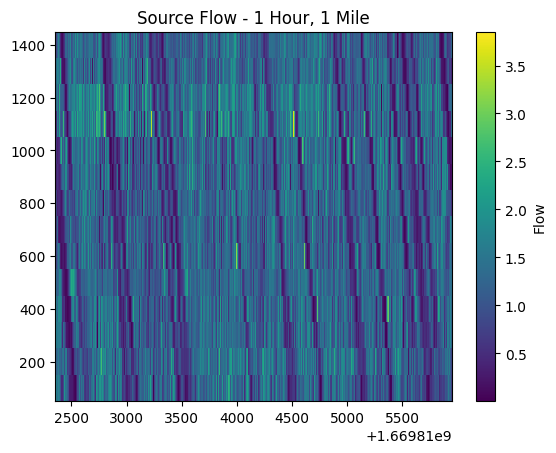

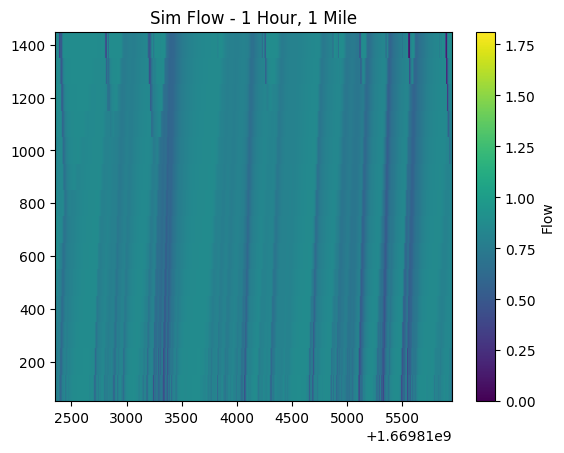

In [123]:
timestamp_min_display = np.array(i24macro_queries["timestamp_min"], dtype=np.float64).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"], dtype=np.float64).reshape((3600, 16))[:, 1:-1].T
density_result_display = np.array(source_density.reshape((3600, 16))[:, 1:-1].T, dtype=np.float64)
jam_scatters = density_result_display > 0.08
jam_time = timestamp_min_display[jam_scatters]
jam_s = s_min_display[jam_scatters]
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.scatter(jam_time, jam_s)
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto')
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
flow_result_display = source_flow.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto')
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

In [ ]:
print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())

In [ ]:
def objective(trial):
    #v_f=33.0, w=5.0, rho_j=0.20
    v_f = trial.suggest_float('v_f', 20.0, 38.0)
    #w = trial.suggest_float('w', 4.5, 8.0)
    #rho_j = 0.09
    rho_j = trial.suggest_float('rho_j', 0.06, 0.12)
    jam_threshold = trial.suggest_float("jam_threshold", 1.0, 20.0)
    #free_threshold = trial.suggest_float("free_threshold", 15.0, 35.0)
    #jam_threshold = 10.0
    free_threshold = jam_threshold
    combined_flow_in_jam_total = 0.0
    combined_flow_in_free_total = 0.0
    for lane in [-1, -2, -3, -4]:
        source_density = i24macro_lane_data[lane]["density"]
        source_flow = i24macro_lane_data[lane]["flow"]
        sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=v_f, rho_j=rho_j)
        sim_flow = sim_flow
        sim_flow_in_jam = ((sim_flow / sim_density) < jam_threshold).astype(int).reshape(-1)
        source_flow_in_jam = (((source_flow[:, 1:-1] / source_density[:, 1:-1]) < jam_threshold)).astype(int).reshape(-1)
        combined_flow_in_jam_source = -(sim_flow_in_jam * source_flow_in_jam).sum() / (source_flow_in_jam.sum() + 1e-12)
        combined_flow_in_jam_sim = -(sim_flow_in_jam * source_flow_in_jam).sum() / (sim_flow_in_jam.sum() + 1e-12)
        combined_flow_in_jam = combined_flow_in_jam_source# + combined_flow_in_jam_sim

        sim_flow_in_free = ((sim_flow / sim_density) > free_threshold).astype(int).reshape(-1)
        source_flow_in_free = (((source_flow[:, 1:-1] / source_density[:, 1:-1]) > free_threshold)).astype(int).reshape(-1)
        combined_flow_in_free_source = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
        combined_flow_in_free_sim = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
        combined_flow_in_free = combined_flow_in_free_source# + combined_flow_in_free_sim


        print(combined_flow_in_jam, combined_flow_in_free)
        combined_flow_in_jam_total += combined_flow_in_jam
        combined_flow_in_free_total += combined_flow_in_free
    return combined_flow_in_jam_total + combined_flow_in_free_total

study = optuna.create_study()
study.optimize(objective, n_trials=250, n_jobs=1)

study.best_params  # E.g. {'x': 2.002108042}

In [ ]:
study.best_params

In [ ]:
source_density = i24macro_lane_data[-4]["density"]
source_flow = i24macro_lane_data[-4]["flow"]
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data(source_density, source_flow, v_f=27.648789930415624, rho_j=0.06475131423016785)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
density_result_display = source_density.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
plt.title('Source Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

density_result_display = sim_density.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
plt.title('Sim Density - 1 Hour, 1 Mile')
plt.colorbar(label='Density')
plt.show()

timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((3600, 16))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((3600, 16))[:, 1:-1].T
flow_result_display = source_flow.reshape((3600, 16))[:, 1:-1].T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
plt.title('Source Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

flow_result_display = sim_flow.reshape((3600, 14)).T
plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
plt.title('Sim Flow - 1 Hour, 1 Mile')
plt.colorbar(label='Flow')
plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())

In [ ]:
plt.hist(sim_flow, bins=np.arange(0, 3.0, 0.1))
plt.ylim(0, 1000)
plt.show()
plt.hist(source_flow, bins=np.arange(0, 3.0, 0.1))
plt.ylim(0, 1000)
plt.show()

# Simulate multiple lanes simultaneously!

In [130]:
def sim_real_data_multilane(lane_data, lane_flow, dx = 100.0, dt = 1.0, v_f=35.0, rho_j=0.10, lambda_lc=0.005):
    time_size = 3600
    longitudinal_range = 16
    lane_data = lane_data.reshape((-1, time_size, 16))
    lane_flow = lane_flow.reshape((-1, time_size, 16))

    # 4 lanes, 200 cells, 20 m per cell = 4 km segment
    lanes = 4
    dx = dx
    dt = dt

    # Typical-ish per-lane params
    fd = TriangularFD(
        v_f=v_f,
        w=0.0,
        rho_j=rho_j
    )

    lane_data_source = lane_data[:, :, :1:-1].reshape((lanes, time_size, longitudinal_range - 2))
    lane_flow_source = lane_flow[:, :, 1:-1].reshape((lanes, time_size, longitudinal_range - 2))
    rho_left_measured = lane_data[:, :, 0].reshape((lanes, time_size, 1))
    rho_right_measured = lane_data[:, :, -1].reshape((lanes, time_size, 1))

    cfg = CTMConfig(dx=dx, dt=dt, lanes=lanes, lambda_lc=lambda_lc)
    ctm = CTMSolver(rho_init=lane_data_source[:, 0, :], fd=fd, cfg=cfg)

    result_density = np.zeros((lanes, time_size, longitudinal_range - 2), dtype=np.float64)
    result_density[:, :, 0] = lane_data_source[:, :, 0]
    result_flow = np.zeros((lanes, time_size, longitudinal_range - 2), dtype=np.float64)
    result_flow[:, :, 0] = lane_flow_source[:, :, 0]
    for k in range(time_size - 1):  # 1 hour
        F, rho = ctm.step(rho_upstream=rho_left_measured[:, k, 0], rho_downstream=rho_right_measured[:, k, 0])
        result_density[:, k+1, :] = rho
        result_flow[:, k + 1, :] = F[:, 1:]
        #result[k+1, 0] = rho_left_measured[:, k, 0]
        #result[k+1, -1] = rho_right_measured[:, k, 0]
        #q_cell, v_cell = ctm.derived_flow_and_speed()
    return result_density, result_flow

In [ ]:
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, 3600, 16) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, 3600, 16) for i in [-1, -2, -3, -4]], axis=0)
print(source_density.shape, source_flow.shape)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow)
sim_flow = sim_flow

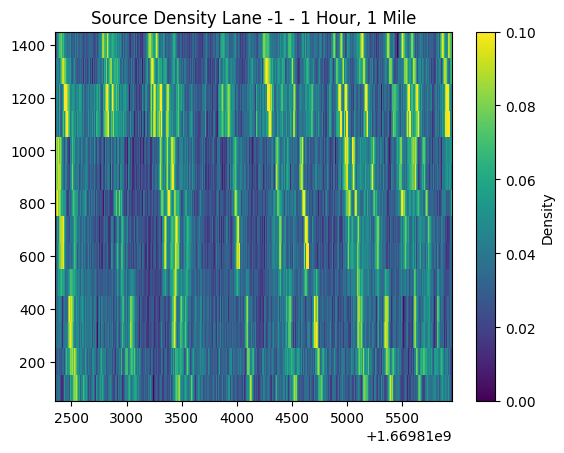

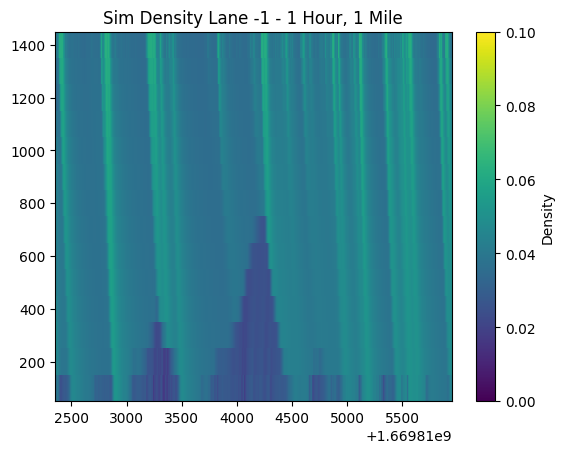

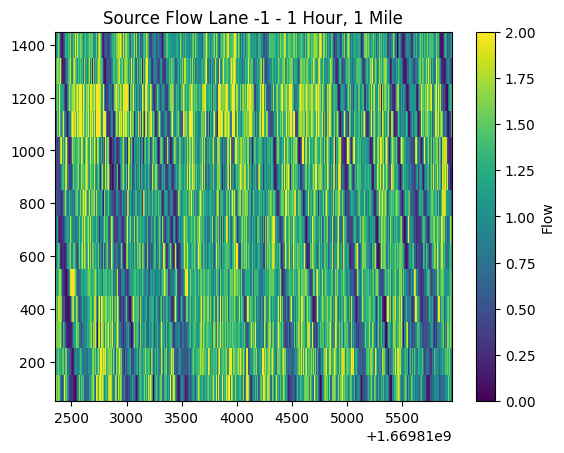

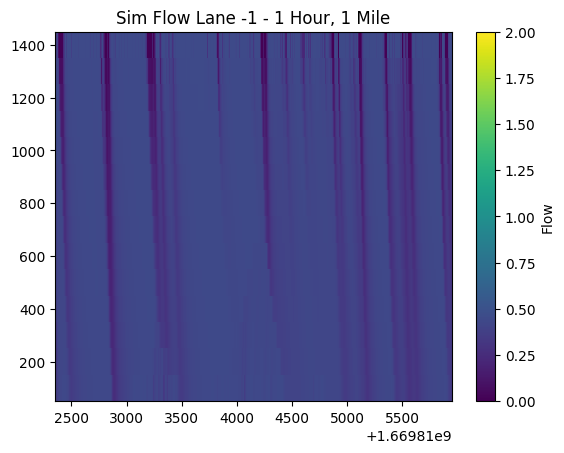

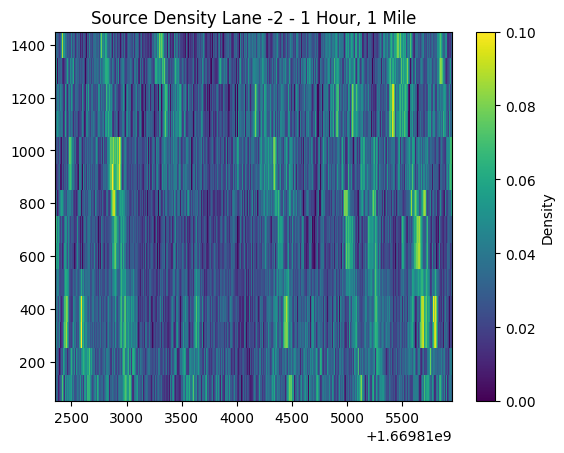

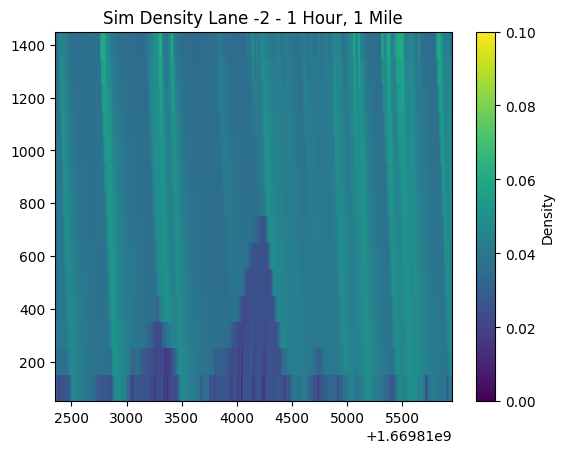

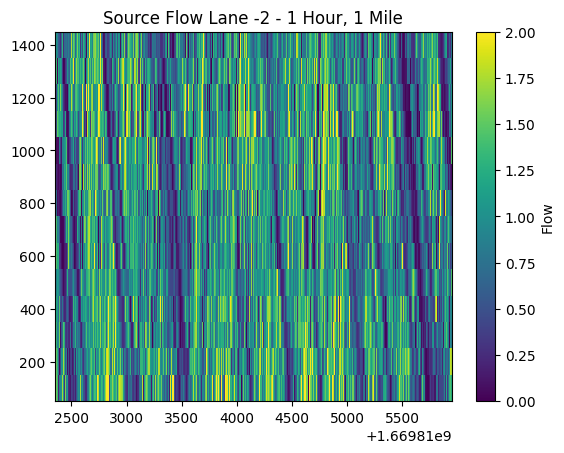

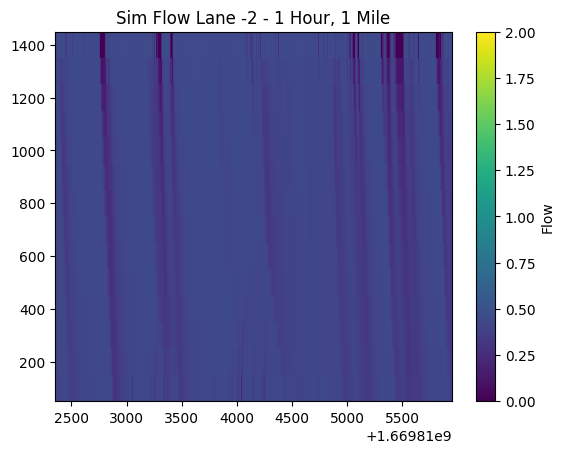

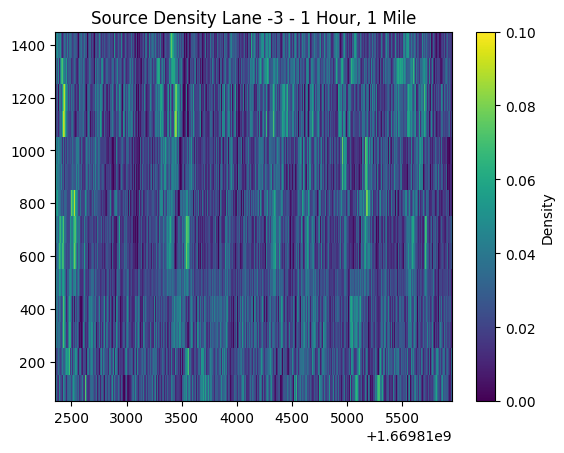

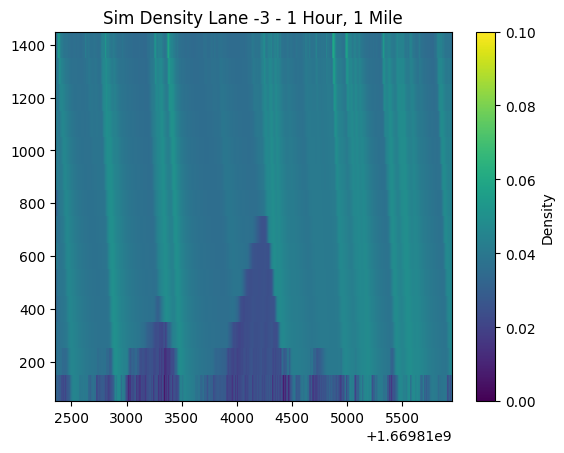

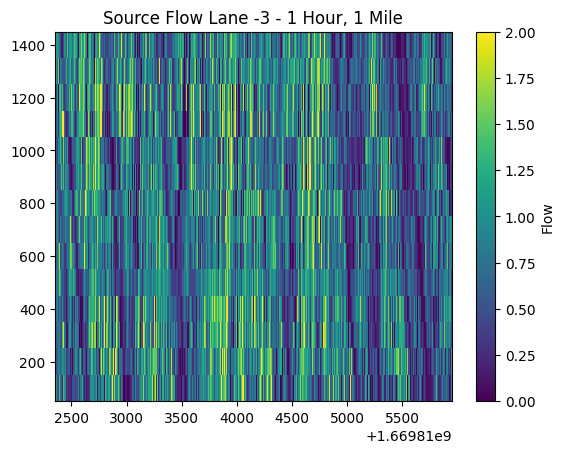

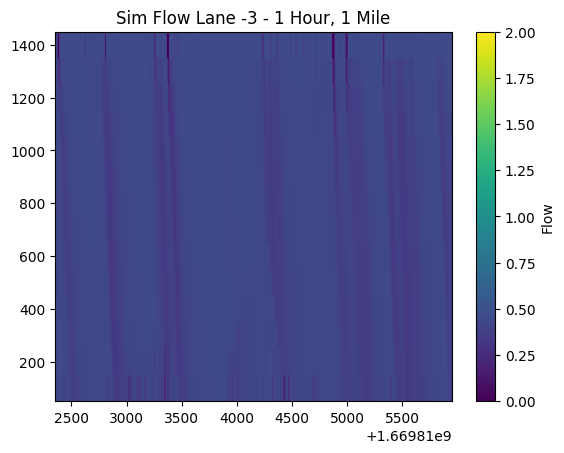

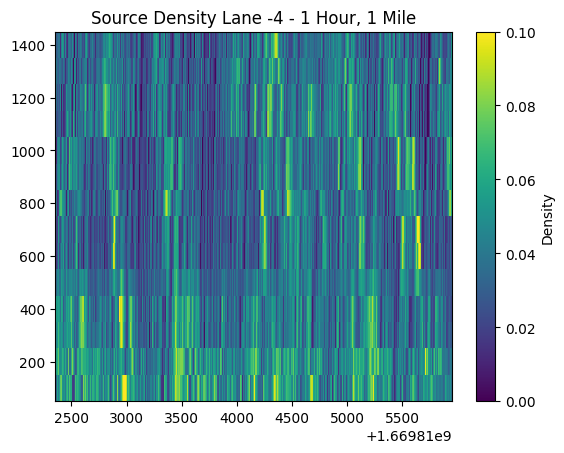

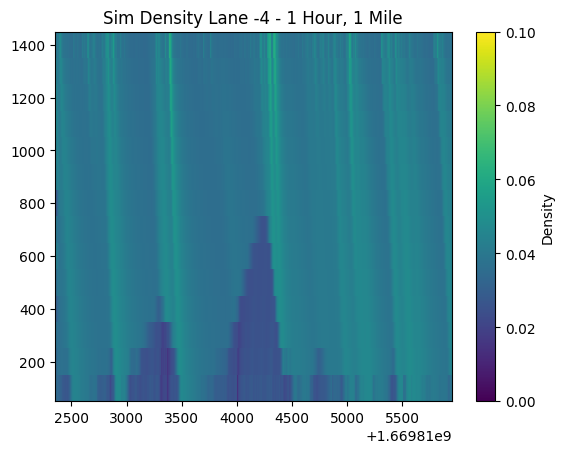

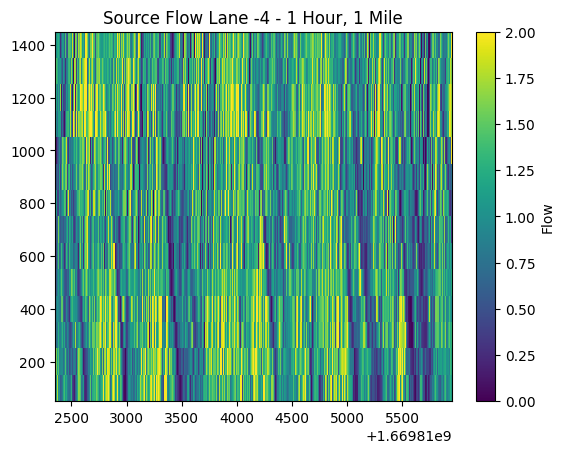

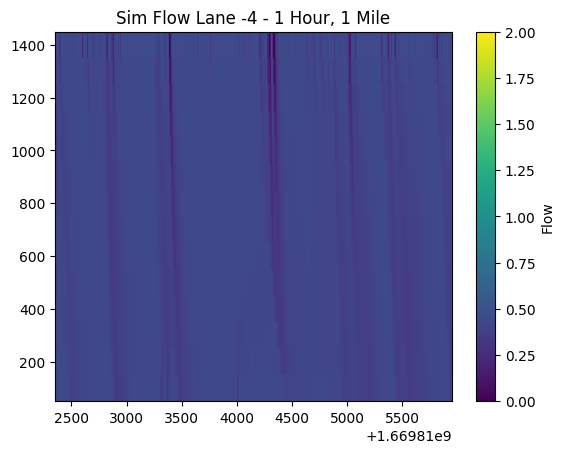

0.0 0.040188351517230214 0.06490729263389272 0.006557932961299259
2.324046e-06 0.034910873 0.1358699 0.017199803
0.0 0.40148772815598643 1.390933871269226 0.05556777445505622
1.4213207e-07 0.99398106 3.9869676 0.505271
0.0 10.43993202859134 41.216083872174245 2.8320358626726847
0.029910343 31.333975 45.000027 13.40267


In [110]:
lanes = 4
time_length = 3600
road_length = 16
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=27.648789930415624, rho_j=0.06475131423016785, lambda_lc=0.005)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T

for i, lane in enumerate([-1, -2, -3, -4]):
    density_result_display = source_density.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Source Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    density_result_display = sim_density.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Sim Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    flow_result_display = source_flow.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Source Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    flow_result_display = sim_flow.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Sim Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())

In [159]:
i = 0
def objective(trial):
    global i
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    #v_f=33.0, w=5.0, rho_j=0.20
    v_f = trial.suggest_float('v_f', 5.0, 45.0)
    #w = trial.suggest_float('w', 4.5, 8.0)
    #rho_j = 0.09
    rho_j = trial.suggest_float('rho_j', 0.05, 0.14)
    #jam_threshold = trial.suggest_float("jam_threshold", 0.1, 25.0)
    #jam_threshold = 15.0
    #lambda_lc = -0.5
    lambda_lc = trial.suggest_float("lambda_lc", 0.0001, 1.0)
    #dy = trial.suggest_float("dy", 2.5, 5.0)
    #free_threshold = trial.suggest_float("free_threshold", 15.0, 35.0)
    jam_threshold = 10.0
    free_threshold = jam_threshold
    combined_flow_in_jam = 0.0
    combined_flow_in_free = 0.0
    source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0).astype(np.float64)
    source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0).astype(np.float64)
    sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=v_f, rho_j=rho_j, lambda_lc=lambda_lc)
    sim_flow_in_jam = ((sim_flow / (sim_density + 1e-12)) < jam_threshold).astype(int).reshape(-1)
    source_flow_in_jam = (((source_flow[:, :, 1:-1] / source_density[:, :, 1:-1]) < jam_threshold)).astype(int).reshape(-1)
    sim_flow_in_free = ((sim_flow / (sim_density + 1e-12)) > free_threshold).astype(int).reshape(-1)
    source_flow_in_free = (((source_flow[:, :, 1:-1] / source_density[:, :, 1:-1]) > free_threshold)).astype(int).reshape(-1)
    combined_flow_in_jam = -(sim_flow_in_jam * source_flow_in_jam).sum() / (source_flow_in_jam.sum() + 1e-12)
    combined_flow_in_free = -(sim_flow_in_free * source_flow_in_free).sum() / (source_flow_in_free.sum() + 1e-12)
    sim_flow_mean, sim_flow_std = sim_flow.mean(), sim_flow.std()
    source_flow_mean, source_flow_std = source_flow.mean(), source_flow.std()
    flow_mean_diff = abs(sim_flow_mean - source_flow_mean)
    flow_std_diff = abs(sim_flow_std - source_flow_std)
    if ((i % 25) == 0):
        print(combined_flow_in_jam + combined_flow_in_free, combined_flow_in_jam, combined_flow_in_free, flow_mean_diff, flow_std_diff)
    i = i + 1
    return combined_flow_in_jam + combined_flow_in_free
    #return flow_mean_diff + flow_std_diff

study = optuna.create_study()
study.optimize(objective, n_trials=2000, n_jobs=1)

study.best_params  # E.g. {'x': 2.002108042}

-1.0000219122851226 -1.0 -2.1912285122654016e-05 0.7834856282952009 0.4893166908723315
-1.0566606371388938 -0.06827962632518106 -0.9883810108137127 0.4830267941145998 0.46607913349431634
-1.1080835820529304 -0.19649417445155873 -0.9115894076013717 0.46195993868519336 0.4465195611859957
-1.346326306785854 -0.652303978167314 -0.69402232861854 0.573408834093606 0.4581946559173878
-1.0349356167233175 -0.9904481998530492 -0.04448741687026832 0.701480740880962 0.45881688414400956
-1.0012544461229997 -0.0016269549700850215 -0.9996274911529148 0.32490381805937585 0.4487090972365379
-1.3189993164928755 -0.8881599664112523 -0.4308393500816233 0.624412630715888 0.45936515997820454
-1.352559567021618 -0.790175291277422 -0.562384275744196 0.6081723770767109 0.45173764453140125
-1.3570486310968026 -0.7073055526398656 -0.6497430784569369 0.585285548649741 0.45520266448107166
-1.2911242091442123 -0.8986039676708303 -0.39252024147338205 0.6282214627986865 0.46286964334825076
-0.9999469822520876 -0.0002

{'v_f': 26.91476041653862,
 'rho_j': 0.06539548928555416,
 'lambda_lc': 0.19539554271314807}

In [127]:
study.best_params

{'v_f': 28.45487660646183,
 'rho_j': 0.06587109566178667,
 'jam_threshold': 10.7383211955908,
 'lambda_lc': 0.025766840703592038}

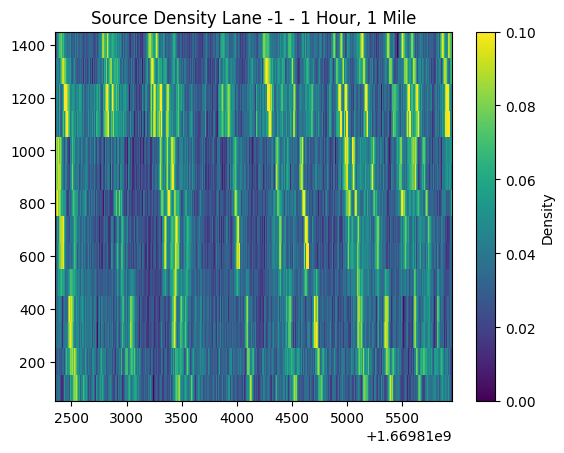

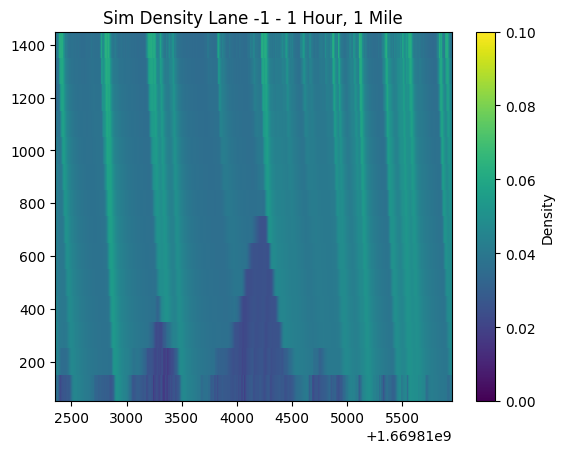

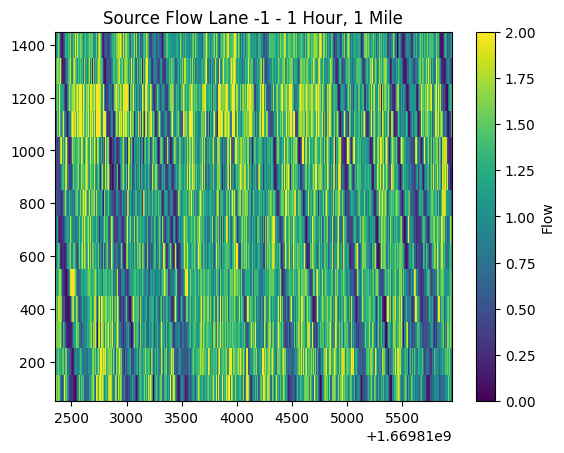

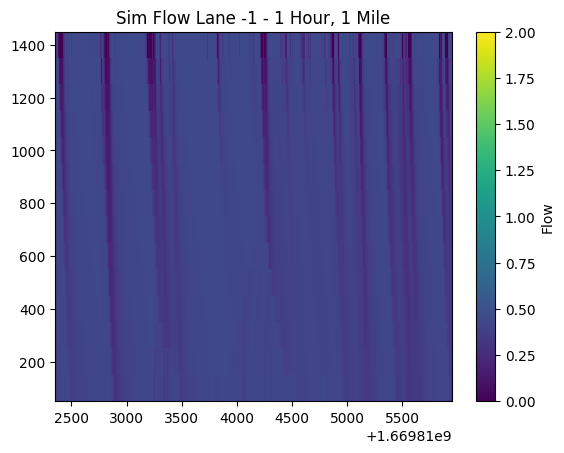

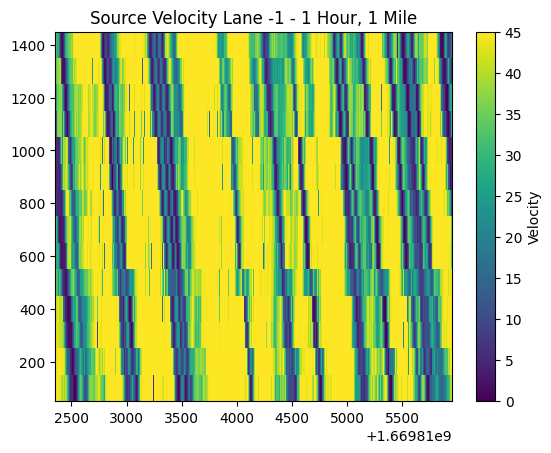

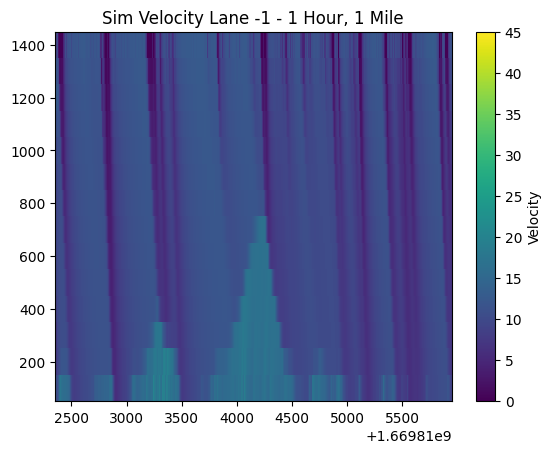

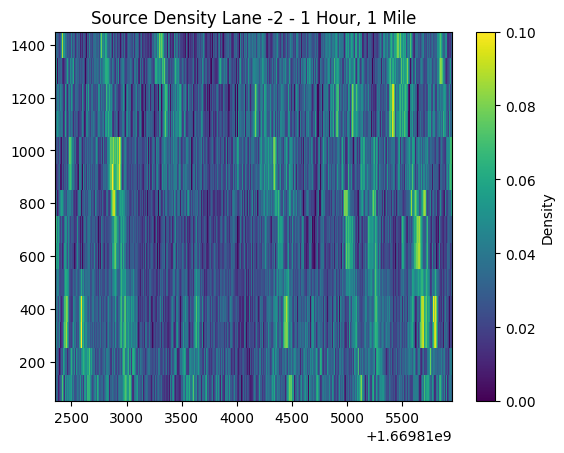

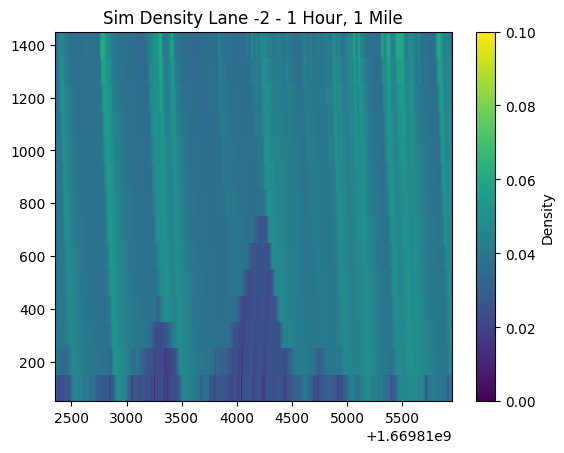

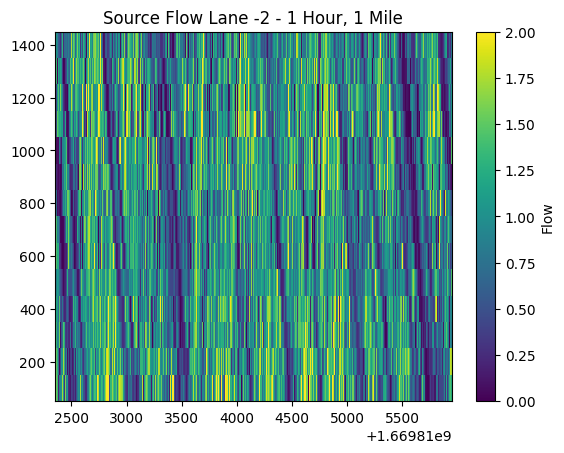

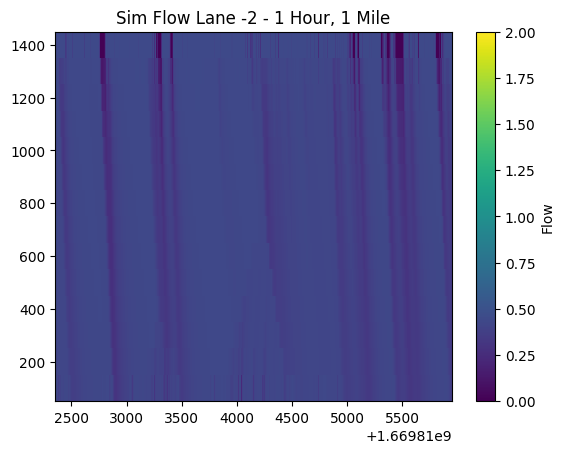

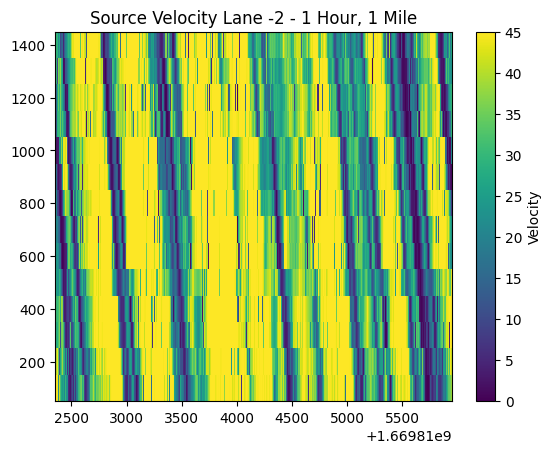

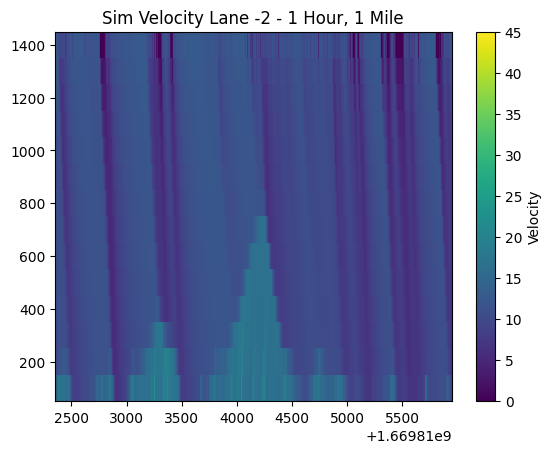

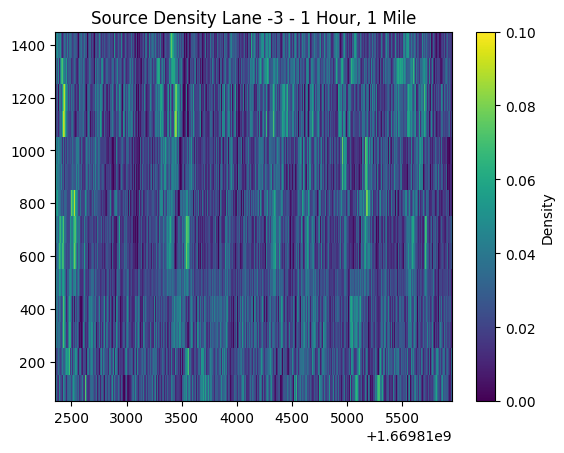

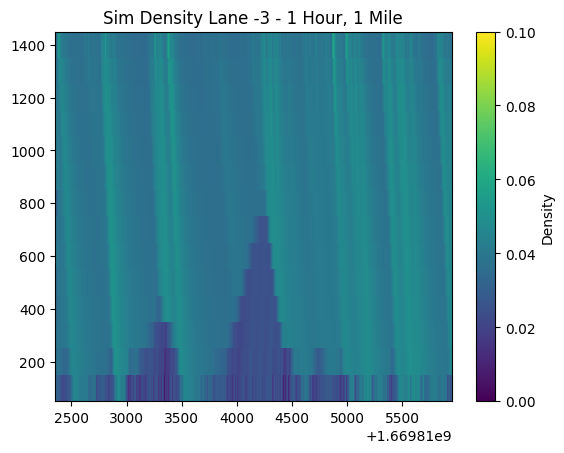

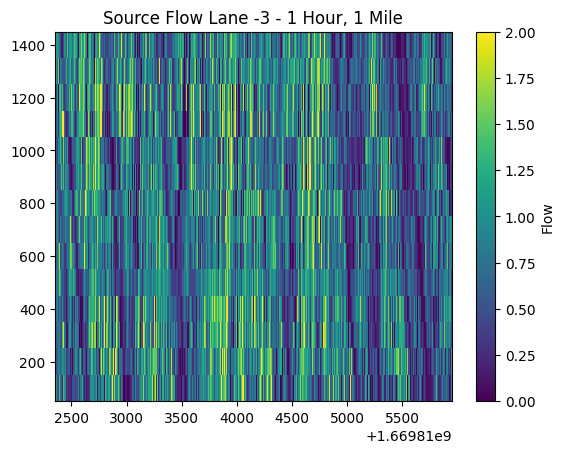

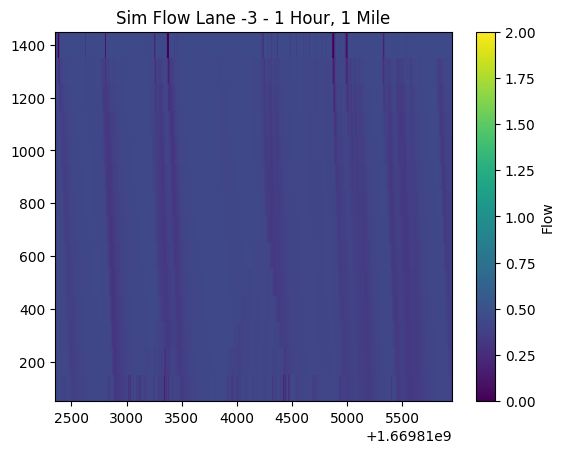

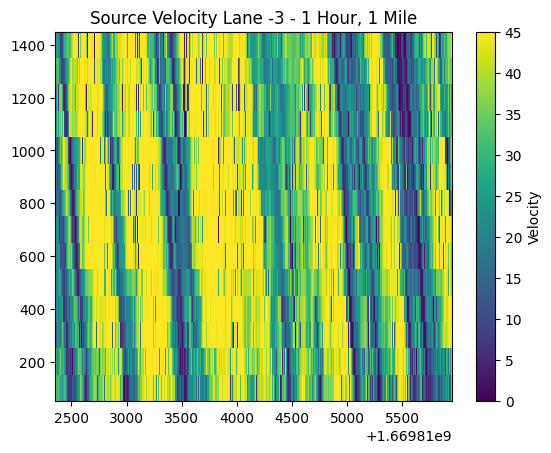

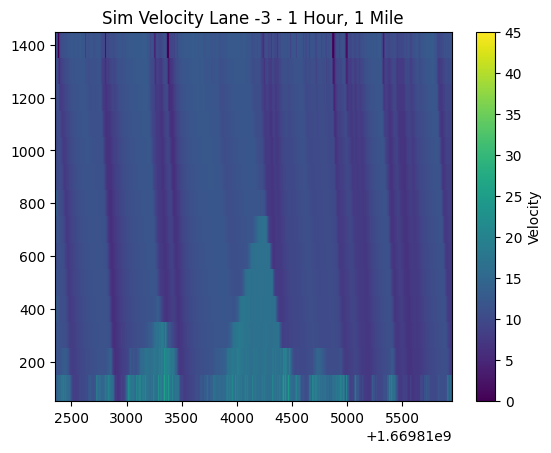

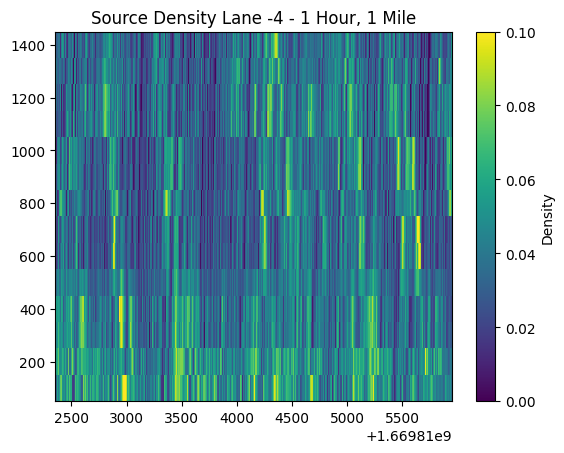

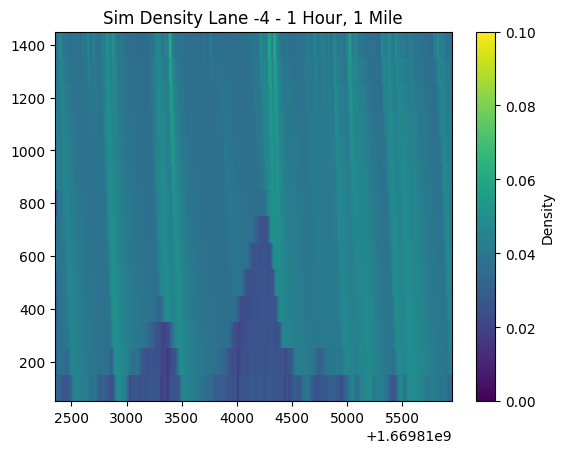

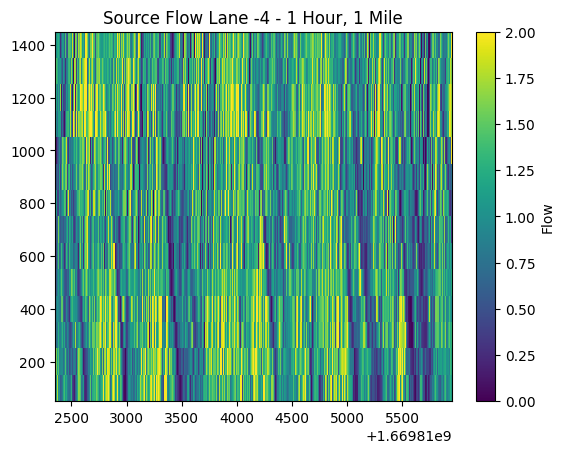

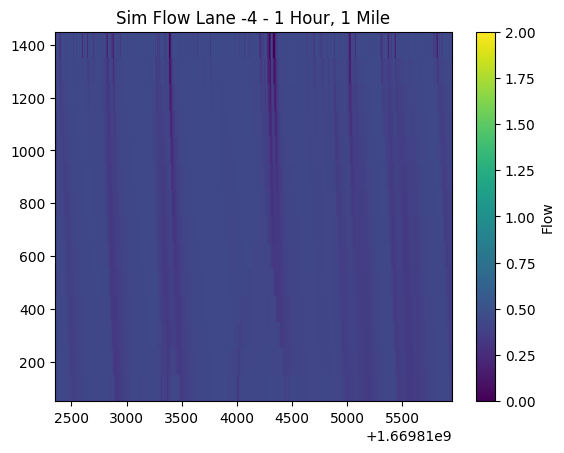

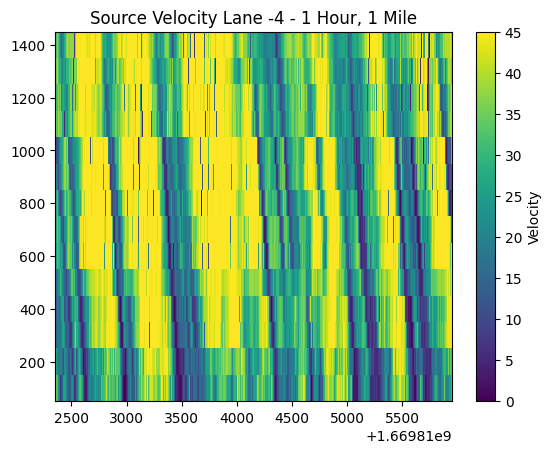

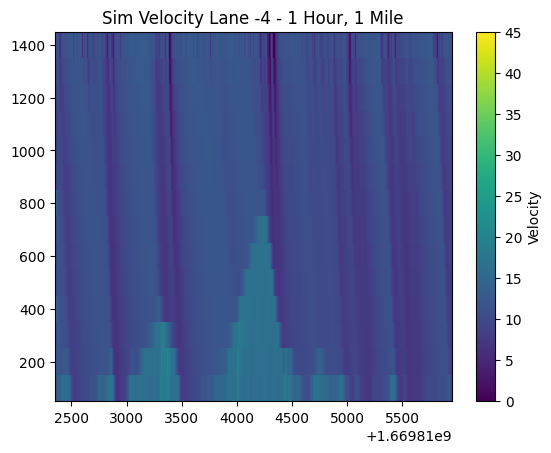

0.0 0.04031052859720663 0.06408177434592043 0.0066262602642167
2.324046e-06 0.034910873 0.1358699 0.017199803
0.0 0.3964504533850932 1.390933871269226 0.05148501553194064
1.4213207e-07 0.99398106 3.9869676 0.505271
0.0 10.275355691306633 41.216083872174245 2.7541496737259887
0.029910343 31.333975 45.000027 13.40267


In [162]:
lanes = 4
time_length = 3600
road_length = 16
source_density = np.concatenate([i24macro_lane_data[i]["density"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_flow = np.concatenate([i24macro_lane_data[i]["flow"].reshape(1, time_length, road_length) for i in [-1, -2, -3, -4]], axis=0)
source_velocity = source_flow / (source_density + 1e-12)
sim_density, sim_flow = sim_real_data_multilane(source_density, source_flow, v_f=26.91476041653862, rho_j=0.06539548928555416, lambda_lc=0.19539554271314807)
sim_velocity = sim_flow / (sim_density + 1e-12)
timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T

for i, lane in enumerate([-1, -2, -3, -4]):
    density_result_display = source_density.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Source Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    density_result_display = sim_density.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, density_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=0.10)
    plt.title(f'Sim Density Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Density')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    flow_result_display = source_flow.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Source Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    flow_result_display = sim_flow.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, flow_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=2.0)
    plt.title(f'Sim Flow Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Flow')
    plt.show()

    timestamp_min_display = np.array(i24macro_queries["timestamp_min"]).reshape((time_length, road_length))[:, 1:-1].T
    s_min_display = np.array(i24macro_queries["s_min"]).reshape((time_length, road_length))[:, 1:-1].T
    velocity_result_display = source_velocity.reshape((lanes, time_length, road_length))[i, :, 1:-1].T
    plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=45.0)
    plt.title(f'Source Velocity Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Velocity')
    plt.show()

    velocity_result_display = sim_velocity.reshape((lanes, time_length, road_length - 2))[i, :, :].T
    plt.pcolormesh(timestamp_min_display, s_min_display, velocity_result_display, cmap='viridis', shading='auto', vmin=0.0, vmax=45.0)
    plt.title(f'Sim Velocity Lane {lane} - 1 Hour, 1 Mile')
    plt.colorbar(label='Velocity')
    plt.show()

print(sim_density.min(), sim_density.mean(), sim_density.max(), sim_density.std())
print(source_density.min(), source_density.mean(), source_density.max(), source_density.std())
print(sim_flow.min(), sim_flow.mean(), sim_flow.max(), sim_flow.std())
print(source_flow.min(), source_flow.mean(), source_flow.max(), source_flow.std())
print(sim_velocity.min(), sim_velocity.mean(), sim_velocity.max(), sim_velocity.std())
print(source_velocity.min(), source_velocity.mean(), source_velocity.max(), source_velocity.std())

np.float64(10.317279631440996)